In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, fsolve, minimize

# Um ressonador

freq 1:  6.944073455759599
freq 2:  13.883138564273791


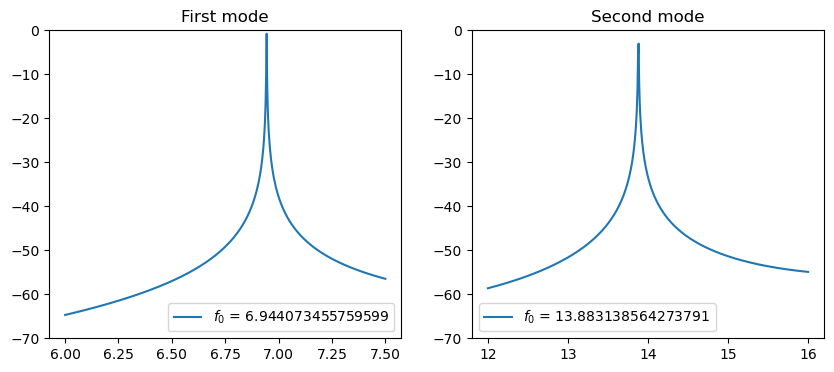

In [176]:
data1 = np.loadtxt('simulation 1 resonator - half wave mode.txt').T
data2 = np.loadtxt('simulation 1 resonator - full wave mode.txt').T

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

x_max = data1[0][np.argmax(data1[1])]
print('freq 1: ',x_max)

ax[0].plot(data1[0],data1[1], label=f'$f_0$ = {x_max}')
ax[0].set_ylim(-70,0)
ax[0].set_title('First mode')
ax[0].legend()
#######################################################

x_max = data2[0][np.argmax(data2[1])]
print('freq 2: ',x_max)

ax[1].plot(data2[0],data2[1], label=f'$f_0$ = {x_max}')
ax[1].set_ylim(-70,0)
ax[1].set_title('Second mode')
ax[1].legend()



# Hexagono

calcula t

In [177]:
f_ghz=13.88 # GHz segundo harmonico
f=f_ghz*1e9 # Hz
C=6.4e-15 #F
l= 8.7*1e-3 # m
C_l=1.7e-10 # F/m
Z=50

t= -(1/2 * f*C*2/(C_l*l))*1e-9

t

-0.060062204192021636

cria a matriz com os elementos diferentes de zero e coloca o valor de t ali

fazer a matriz hexagono 


In [178]:

indexes = [(0,1),(1,2),(2,3),(3,4),(4,5),(5,0),(1,0),(2,1),(3,2),(4,3),(5,4),(0,5)]
ALG = np.zeros((6,6))

for i in range(0,12):
    ALG[indexes[i][0]][indexes[i][1]] = 1

ALG


array([[0., 1., 0., 0., 0., 1.],
       [1., 0., 1., 0., 0., 0.],
       [0., 1., 0., 1., 0., 0.],
       [0., 0., 1., 0., 1., 0.],
       [0., 0., 0., 1., 0., 1.],
       [1., 0., 0., 0., 1., 0.]])

diagonaliza a matriz e recebe os autovalores dela

In [179]:
# list of eigenvalues

ev = np.sort(np.linalg.eigvals(ALG))
ev

array([-2., -1., -1.,  1.,  1.,  2.])

In [180]:
# Expeted frequencies

diagonal = f_ghz*np.ones(6)
H = -t*ALG
np.fill_diagonal(H,diagonal)

ideal_eigenv = np.sort(np.linalg.eigvals(H))
print(H, ideal_eigenv)

[[13.88       0.0600622  0.         0.         0.         0.0600622]
 [ 0.0600622 13.88       0.0600622  0.         0.         0.       ]
 [ 0.         0.0600622 13.88       0.0600622  0.         0.       ]
 [ 0.         0.         0.0600622 13.88       0.0600622  0.       ]
 [ 0.         0.         0.         0.0600622 13.88       0.0600622]
 [ 0.0600622  0.         0.         0.         0.0600622 13.88     ]] [13.75987559 13.8199378  13.8199378  13.9400622  13.9400622  14.00012441]


# Hexagono realista

In [11]:
13.883138564273791- 13.568

0.3151385642737914

In [2]:
f_ghz=13.883138564273791 - 0.3151385642737914 # GHz segundo harmonico
f=f_ghz*1e9 # Hz
C=np.array([6.1, 6.54, 6.11, 6.11, 6.54, 6.11])*1e-15 - 0.5e-15 #F
l= 8.7*1e-3 # m
C_l=1.7e-10 # F/m
Z=50

t= -(1/2 * f*C*2/(C_l*l))*1e-9

t

array([-0.05137309, -0.05540955, -0.05146483, -0.05146483, -0.05540955,
       -0.05146483])

In [3]:

indexes = [(0,1),(1,2),(2,3),(3,4),(4,5),(5,0),(1,0),(2,1),(3,2),(4,3),(5,4),(0,5)]
ALG = -np.zeros((6,6))

n = 0
for i in range(0,6):
    ALG[indexes[i][0]][indexes[i][1]] = t[n]
    n += 1
n = 0
for i in range(6,12):
    ALG[indexes[i][0]][indexes[i][1]] = t[n]
    n += 1

diagonal = f_ghz*np.ones(6)
H = -ALG
np.fill_diagonal(H,diagonal)

hexagon_eigenv = np.sort(np.linalg.eigvals(H))
print(H, hexagon_eigenv)

[[13.568       0.05137309  0.          0.          0.          0.05146483]
 [ 0.05137309 13.568       0.05540955  0.          0.          0.        ]
 [ 0.          0.05540955 13.568       0.05146483  0.          0.        ]
 [ 0.          0.          0.05146483 13.568       0.05146483  0.        ]
 [ 0.          0.          0.          0.05146483 13.568       0.05540955]
 [ 0.05146483  0.          0.          0.          0.05540955 13.568     ]] [13.46244861 13.51259032 13.51785833 13.61814167 13.62340968 13.67355139]


## Resultado da simulação

(13.4, 13.7)

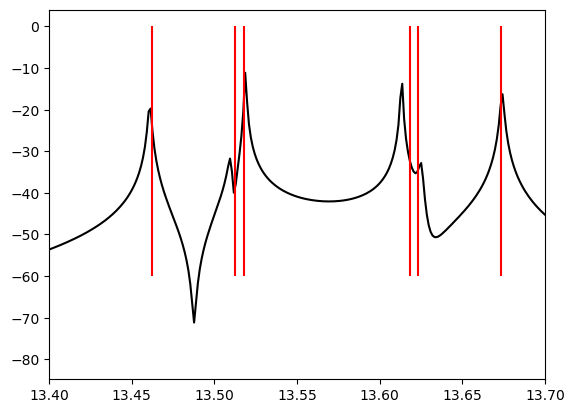

In [4]:
h21 = np.loadtxt('simulation hexagon S21.txt').T

plt.plot(h21[0],h21[1], 'k')
plt.vlines(hexagon_eigenv,-60, 0, 'r')

plt.xlim(13.4, 13.7)

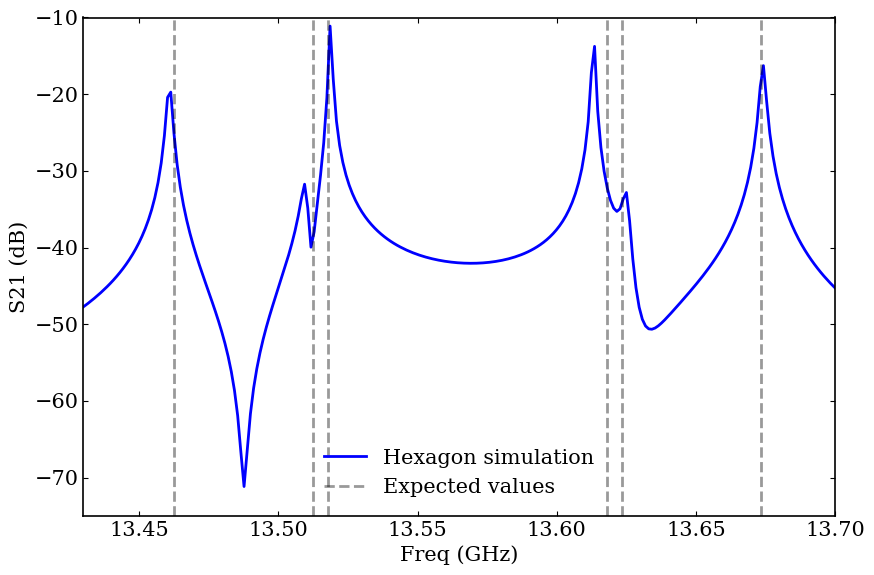

In [8]:
# ---------- Configuração estilo científico ----------
plt.rcParams.update({
    "font.size": 15,
    "font.family": "serif",
    "axes.linewidth": 1.2,
    "lines.linewidth": 2,
    "lines.markersize": 6,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "legend.frameon": False
})

# ---------- Figura ----------
fig, ax = plt.subplots(figsize=(9,6))

ax.plot(h21[0], h21[1], '-b', label="Hexagon simulation")

# ---------- Valores esperados ----------
for i, val in enumerate(hexagon_eigenv):
    plt.axvline(val, linestyle="--", color="black",
                alpha=0.4,
                label="Expected values" if i==0 else "")

# ---------- Eixos ----------
ax.set_xlabel("Freq (GHz)")
ax.set_ylabel("S21 (dB)")

# ---------- Limites ----------
ax.set_xlim(13.43, 13.7)
ax.set_ylim(-75,-10)

# ---------- Grade opcional ----------
#ax.grid(alpha=0.3)

# ---------- Legenda ----------
ax.legend()

# ---------- Ajuste layout ----------
plt.tight_layout()

# ---------- Salvar figura ----------
plt.savefig("grafico_artigo.png", dpi=600)

plt.show()

# Fit da curva

É apenas um teste. Ainda não deu certo, acho que precisa de mais pontos no grafico para fazer o fit, e a amplitude de cada Lorentziana talvez tenha que ser diferente

In [55]:
# Fit com 3 picos
def modelo(x, pico1, pico2, pico3, pico4, pico5, pico6):
    G=0.001
    pico = np.array([pico1, pico2, pico3, pico4, pico5, pico6])
    return sum(4e-3*(G/((x-p)**2+(G/2)**2)) for p in pico)

[13.73201696 13.73201696 13.73201982 13.73201751 13.73202371 13.73192256]


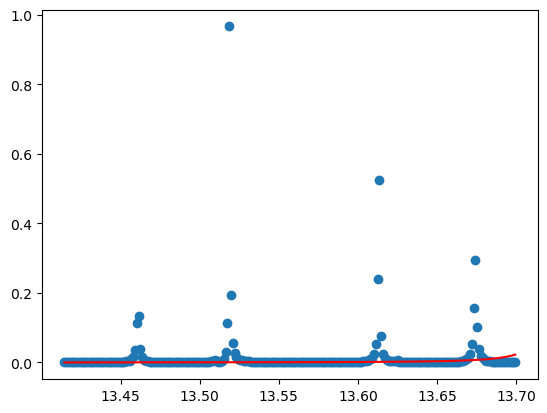

In [56]:
y_data = (10**((h21[1]-30)/10)/8e-5)[100:350] # Eixo y linear normalizado para 1, no range que me interassa
x_data = h21[0][100:350] # eixo x no range que interessa
# plt.plot(x_data,y_data)
# y_datafit = modelo(x_data, 13.45, 13.5, 13.55, 13.6, 13.65, 13.7)
# plt.plot(x_data, y_datafit/4000)

parametros_otimos, aux = curve_fit(modelo, x_data, y_data)
y_datafit = modelo(x_data, *parametros_otimos)

print(parametros_otimos)
plt.scatter(x_data, y_data)
plt.plot(x_data, y_datafit, color='red')